# 02 — Results: how good are the forecasts?

This notebook compares every model on the **test period (2025-01-01 onwards)**, which was never used to choose or tune anything (see D8 in `docs/decisions.md`). It answers five questions:

1. Which model is most accurate, and by how much does it beat the naive baseline?
2. How fast does the error grow with the horizon?
3. What do the forecasts look like against what actually happened?
4. Are the 80 % intervals honest?
5. Where (which region) is forecasting hardest?

The forecasts are read from `data/forecasts/`, written by each model's evaluation run (`python -m src.lgbm --test`, `python -m src.lstm --test`, and so on). They are not versioned; re-run the models to regenerate them. The key findings are summarised at the end.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.evaluation import FORECASTS_DIR, TEST, in_period, score

plt.rcParams.update({
    "figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.35, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.precision", 2)

# Categorical palette (fixed order) and neutrals, as on the public page.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, GREY = "#52514e", "#898781"

KEYS = ["origin", "target_date", "horizon", "ars"]
FOUR = ["lightgbm", "lstm", "sarimax", "chronos2"]
NAMES = {
    "seasonal_naive": "Seasonal naive", "last_value": "Last value", "ets": "ETS", "nhits": "N-HiTS",
    "lstm": "LSTM", "sarimax": "SARIMAX", "chronos2": "Chronos-2 (zero-shot)", "lightgbm": "LightGBM",
    "average": "Average of 4 models",
}

def load(model, target):
    return pd.read_parquet(FORECASTS_DIR / f"{model}_{target}_test.parquet")

def four_model_average(target):
    merged = None
    for model in FOUR:
        part = load(model, target).rename(columns={"y_pred": model})
        merged = part if merged is None else merged.merge(part[KEYS + [model]], on=KEYS)
    merged["y_pred"] = merged[FOUR].mean(axis=1)
    return merged

def forecasts(model, target):
    return four_model_average(target) if model == "average" else load(model, target)

## 1. Model comparison

Mean absolute error (MAE) averaged over the five series, for horizons 1–7 and 8–14 days after the latest official data. ETS and N-HiTS were only evaluated up to 7 days.

In [2]:
MODELS = ["last_value", "seasonal_naive", "ets", "nhits", "lstm", "sarimax", "chronos2", "lightgbm", "average"]

rows = []
for model in MODELS:
    row = {"model": NAMES[model]}
    for target, label in [("wait_minutes", "wait"), ("episodes", "episodes")]:
        table = score(forecasts(model, target), TEST)
        row[f"{label} 1-7"] = table.loc["Média", "1-7"]
        row[f"{label} 8-14"] = table.loc["Média", "8-14"] if "8-14" in table.columns else None
    rows.append(row)
comparison = pd.DataFrame(rows).set_index("model")
naive = comparison.loc["Seasonal naive"]
comparison["wait: gain vs naive"] = (1 - comparison["wait 1-7"] / naive["wait 1-7"]).map("{:+.0%}".format)
comparison

,wait 1-7,wait 8-14,episodes 1-7,episodes 8-14,wait: gain vs naive
model,,,,,
Last value,8.98,10.09,635.73,670.93,-18%
Seasonal naive,7.63,8.76,278.22,366.19,+0%
ETS,6.87,NaN,248.87,NaN,+10%
N-HiTS,6.66,NaN,249.47,NaN,+13%
LSTM,6.34,6.96,226.16,268.70,+17%
SARIMAX,6.05,6.97,231.22,309.56,+21%
Chronos-2 (zero-shot),5.93,6.68,216.40,281.68,+22%
LightGBM,5.92,6.61,218.90,276.59,+22%
Average of 4 models,5.73,6.40,198.81,255.92,+25%


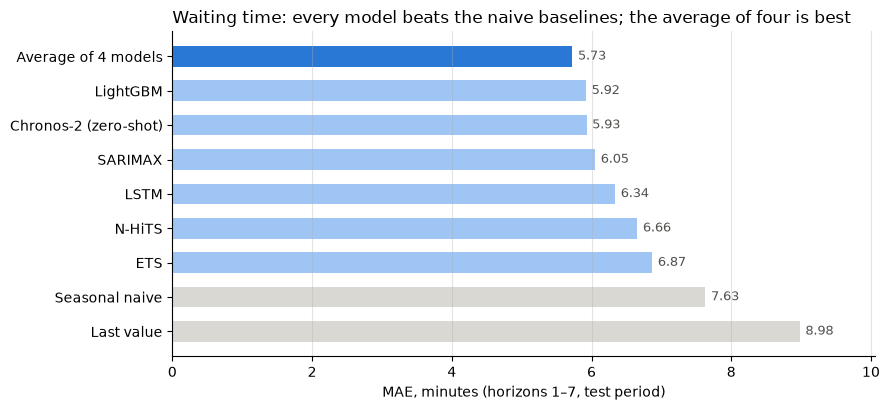

In [3]:
order = comparison["wait 1-7"].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.2))
baselines = ("Seasonal naive", "Last value")
colors = [BLUE if name == "Average of 4 models" else ("#d9d8d2" if name in baselines else "#9ec5f4") for name in order.index]
ax.barh(order.index, order.values, color=colors, height=0.6)
for y, value in enumerate(order.values):
    ax.text(value + 0.08, y, f"{value:.2f}", va="center", fontsize=9, color=INK)
ax.set_xlabel("MAE, minutes (horizons 1–7, test period)")
ax.set_title("Waiting time: every model beats the naive baselines; the average of four is best", loc="left")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, order.max() * 1.12)
plt.tight_layout()

## 2. Error by horizon

How much accuracy is lost as the forecast reaches further ahead. Horizon 1 is the day after the latest official data.

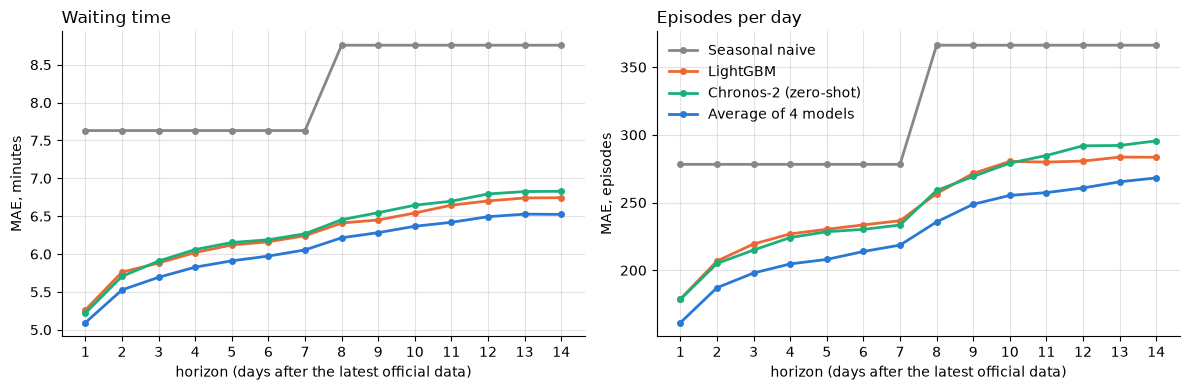

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target, unit in [(axes[0], "wait_minutes", "minutes"), (axes[1], "episodes", "episodes")]:
    for model, color in [("seasonal_naive", GREY), ("lightgbm", ORANGE), ("chronos2", AQUA), ("average", BLUE)]:
        table = score(forecasts(model, target), TEST)
        by_h = table.loc["Média", [h for h in range(1, 15) if h in table.columns]]
        ax.plot(by_h.index, by_h.values, color=color, label=NAMES[model], marker="o", markersize=4)
    ax.set_xlabel("horizon (days after the latest official data)")
    ax.set_ylabel(f"MAE, {unit}")
    ax.set_xticks(range(1, 15))
axes[0].set_title("Waiting time", loc="left")
axes[1].set_title("Episodes per day", loc="left")
axes[1].legend(frameon=False, loc="upper left")
plt.tight_layout()

The seasonal naive is flat for horizons 1–7 because it always copies the same weekday of the latest known week; it jumps at 8, when it has to reach two weeks back. The models lose accuracy slowly.

## 3. Forecast against reality

Mainland Portugal, test period. Each point is the forecast made 1 day (top) or 7 days (bottom) before the date, against the value the SNS later published.

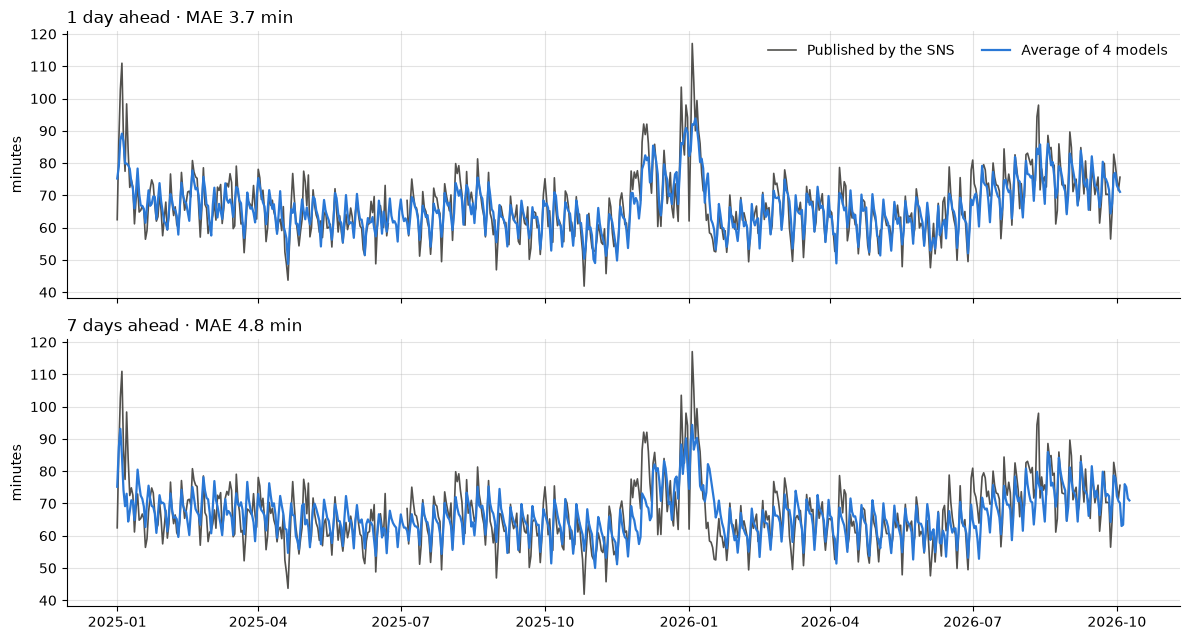

In [5]:
avg = four_model_average("wait_minutes")
region = "Portugal Continental"
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
for ax, horizon in zip(axes, [1, 7]):
    part = avg[(avg["ars"] == region) & (avg["horizon"] == horizon)]
    part = part[in_period(part["target_date"], TEST)].sort_values("target_date")
    ax.plot(part["target_date"], part["y_true"], color=INK, linewidth=1.2, label="Published by the SNS")
    ax.plot(part["target_date"], part["y_pred"], color=BLUE, linewidth=1.6, label="Average of 4 models")
    mae = (part["y_true"] - part["y_pred"]).abs().mean()
    ax.set_title(f"{horizon} day{'s' if horizon > 1 else ''} ahead · MAE {mae:.1f} min", loc="left")
    ax.set_ylabel("minutes")
axes[0].legend(frameon=False, loc="upper right", ncol=2)
plt.tight_layout()

The forecast follows the weekly rhythm and the winter peaks. It smooths the most extreme single days, which no model can see coming from the available data.

## 4. Are the 80 % intervals honest?

Share of test days whose published value falls inside the calibrated interval (quantile LightGBM plus conformal margins, D14). The target is 80 %.

horizon,1,2,3,4,5,6,7,8,9,10,11,12,13,14
target,,,,,,,,,,,,,,
episodes,79.6,80.0,81.4,82.6,81.3,81.4,82.0,81.1,81.4,79.8,79.2,79.1,79.8,79.4
wait_minutes,84.0,85.0,84.7,84.5,84.2,85.7,85.6,85.0,86.1,85.1,85.2,84.5,84.7,85.2


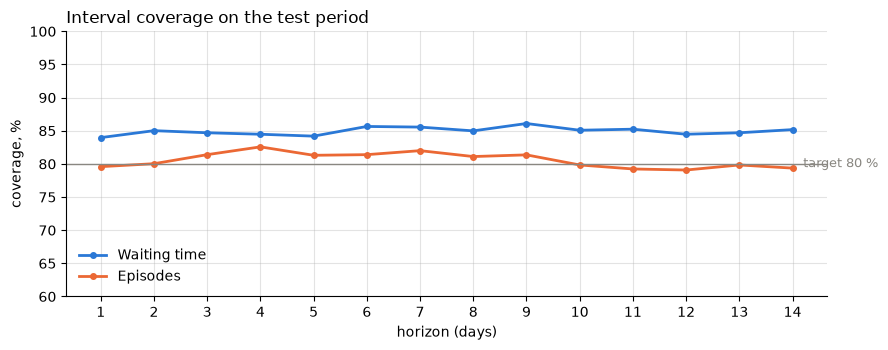

In [6]:
rows = []
for target in ["wait_minutes", "episodes"]:
    iv = pd.read_parquet(FORECASTS_DIR / f"lightgbm_intervals_{target}_test.parquet")
    iv = iv[in_period(iv["target_date"], TEST)].dropna(subset=["y_true"])
    inside = iv["y_true"].between(iv["y_low"], iv["y_high"])
    for horizon, value in inside.groupby(iv["horizon"]).mean().items():
        rows.append({"target": target, "horizon": horizon, "coverage": value})
coverage = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 3.6))
labels = {"wait_minutes": "Waiting time", "episodes": "Episodes"}
for target, color in [("wait_minutes", BLUE), ("episodes", ORANGE)]:
    part = coverage[coverage["target"] == target]
    ax.plot(part["horizon"], part["coverage"] * 100, color=color, marker="o", markersize=4, label=labels[target])
ax.axhline(80, color=GREY, linewidth=1)
ax.text(14.2, 80, "target 80 %", va="center", fontsize=9, color=GREY)
ax.set_ylim(60, 100)
ax.set_xticks(range(1, 15))
ax.set_xlabel("horizon (days)")
ax.set_ylabel("coverage, %")
ax.legend(frameon=False, loc="lower left")
ax.set_title("Interval coverage on the test period", loc="left")
plt.tight_layout()
coverage.pivot(index="horizon", columns="target", values="coverage").mul(100).round(1).T

Coverage is close to the promised 80 % at every horizon. For the waiting time it is slightly above (about 85 %): the margins were learnt on 2023–2024, which was more volatile than 2025–2026, so the intervals are a little generous. That is the safe side for planning.

## 5. Error by region

In [7]:
table = score(four_model_average("wait_minutes"), TEST)[["1-7", "8-14"]].drop("Média")
naive_table = score(load("seasonal_naive", "wait_minutes"), TEST)[["1-7"]].drop("Média")
table["seasonal naive 1-7"] = naive_table["1-7"]
table.index = [name.replace("ARS ", "") for name in table.index]
table

horizon,1-7,8-14,seasonal naive 1-7
Norte,4.07,4.62,5.73
Centro,6.19,6.93,7.90
Lisboa e Vale do Tejo,9.28,10.48,12.21
Alentejo,4.63,4.75,6.18
Portugal Continental,4.45,5.24,6.14


Lisboa e Vale do Tejo is the hardest region: it has the longest and most volatile waits (EDA, section 2), and its error is about twice the Norte's. The Algarve is not in the table: its waiting-time series is too incomplete to evaluate (D7, D19).

## Key findings

1. **The four-model average is the best forecaster**: about 5.7 minutes of error at 1–7 days and 6.4 at 8–14 days on the waiting time, 25 % better than the seasonal naive (7.6 minutes). For episodes it is 28 % better (199 vs. 278 per day).
2. **A simple model, well fed, beats deep learning on this data.** LightGBM (5.9) beats the LSTM written from scratch (6.3) and N-HiTS (6.7). A classical SARIMAX with three calendar variables (6.1) also beats both networks. With about 3,500 days per series, this matches the literature (`docs/literature.md`).
3. **A foundation model ties with the best trained model without seeing any SNS data.** Chronos-2 zero-shot scores 5.9 minutes, the same as LightGBM trained on 10 years of data.
4. **Averaging models with different errors helps**: every combination of two or more models beat the best single model, on both periods.
5. **The intervals are honest**: the actual value falls inside the 80 % interval on 81–85 % of test days, at every horizon.
6. **The second week is almost as good as the first** for the waiting time (+0.7 minutes); for episodes it costs more (+29 %).